# IRRM-CODEC inverse: run and analyze

This notebook mirrors the forward example, but trains and evaluates the inverse model that reconstructs a CDR3 sequence from a TCRemP embedding.

## 1. Define inputs

The AIRR file must contain `clone_id`, `junction_aa`, `v_call`, `j_call`, `locus`.
The embeddings parquet must contain `clone_id` plus either `tcremp_emb` or numeric embedding columns.

In [1]:
from pathlib import Path

root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
airr_path = '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv'  # root / 'data' / 'sample_airr.tsv'
embeddings_path = '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet'
output_dir = root / 'artifacts' / 'inverse_demo_trb'

airr_path, embeddings_path, output_dir

('/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 PosixPath('/home/evlasova/irrm-codec/artifacts/inverse_demo_trb'))

In [2]:
import sys

sys.path.insert(0, str(root))

## 2. Preview the two files

In [3]:
import pandas as pd

airr_df = pd.read_csv(airr_path, sep='\t')
emb_df = pd.read_parquet(embeddings_path)

display(airr_df.head())
display(emb_df.head())

,junction_aa,v_call,j_call,locus
0,CATSDPGTGHQPQHF,TRBV24-1,TRBJ1-5,beta
1,CAISEGLGQGETQYF,TRBV10-3,TRBJ2-5,beta
2,CASSQVGTGVYEQYF,TRBV3-1,TRBJ2-7,beta
3,CASSLGADTQYF,TRBV13,TRBJ2-3,beta
4,CASSRTGNEQYF,TRBV27,TRBJ2-7,beta


,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,2_b_v,2_b_j,2_b_cdr3,3_b_v,...,2996_b_cdr3,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3
0,510.0,0.0,1070.0,444.0,221.0,1200.0,776.0,0.0,890.0,776.0,...,1100.0,697.0,221.0,980.0,682.0,196.0,1320.0,488.0,196.0,890.0
1,398.0,223.0,1410.0,464.0,198.0,1120.0,782.0,223.0,1070.0,782.0,...,720.0,727.0,198.0,1040.0,686.0,197.0,1460.0,428.0,197.0,1070.0
2,775.0,221.0,1330.0,709.0,0.0,820.0,423.0,221.0,990.0,423.0,...,1160.0,670.0,0.0,680.0,615.0,107.0,1080.0,765.0,107.0,730.0
3,765.0,212.0,1460.0,761.0,213.0,730.0,709.0,212.0,1200.0,709.0,...,850.0,434.0,213.0,770.0,453.0,202.0,1090.0,763.0,202.0,580.0
4,376.0,221.0,1400.0,0.0,0.0,750.0,768.0,221.0,1120.0,768.0,...,1170.0,689.0,0.0,730.0,712.0,107.0,1210.0,492.0,107.0,500.0


## 3. Launch training

In [18]:
import subprocess

cmd = [
    sys.executable, '-m', 'irrm_codec.train_inverse',
    '--airr-path', str(airr_path),
    '--embeddings-path', str(embeddings_path),
    '--output-dir', str(output_dir),
    '--locus', 'beta',
    '--epochs', '25',
    '--max-len', '30',
    '--weight-decay', '0.00001',
    '--lr', '0.001'
]
subprocess.run(cmd, cwd=root, check=True)
cmd

2026-04-02 01:07:02,042 | INFO | starting inverse training
2026-04-02 01:07:02,050 | INFO | output_dir=/home/evlasova/irrm-codec/artifacts/inverse_demo_trb
2026-04-02 01:07:02,051 | INFO | device=cuda seed=42
2026-04-02 01:07:02,051 | INFO | hyperparameters batch_size=128 epochs=25 lr=0.001000 weight_decay=0.000500 max_len=30 num_workers=0 log_interval=10
2026-04-02 01:07:35,482 | INFO | loaded data total=100000 train=80000 val=10000 test=10000 embedding_dim=9000
2026-04-02 01:07:35,482 | INFO | dataloader batches train=625 val=79 test=79
2026-04-02 01:07:35,482 | INFO | model parameters total=44082743 trainable=44082743
2026-04-02 01:07:35,499 | INFO | epoch 1/25 started
2026-04-02 01:07:54,243 | INFO | saved checkpoint path=/home/evlasova/irrm-codec/artifacts/inverse_demo_trb/last.pt     
2026-04-02 01:07:55,062 | INFO | new best checkpoint path=/home/evlasova/irrm-codec/artifacts/inverse_demo_trb/best.pt val_loss=0.3280
2026-04-02 01:07:55,062 | INFO | epoch=1 summary train_loss=0.7

['/home/evlasova/.conda/envs/irrm-codec/bin/python',
 '-m',
 'irrm_codec.train_inverse',
 '--airr-path',
 '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 '--embeddings-path',
 '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 '--output-dir',
 '/home/evlasova/irrm-codec/artifacts/inverse_demo_trb',
 '--locus',
 'beta',
 '--epochs',
 '25',
 '--max-len',
 '30',
 '--weight-decay',
 '0.0005',
 '--lr',
 '0.001']

## 4. Inspect saved metrics and merge stats

In [5]:
import json
import pandas as pd

history = json.loads((output_dir / 'history.json').read_text())
test_metrics = json.loads((output_dir / 'test_metrics.json').read_text())
data_stats = json.loads((output_dir / 'data_stats.json').read_text())
history_df = pd.json_normalize(history)

display(history_df)
display(test_metrics)
display(data_stats)

,epoch,train.loss,train.token_accuracy,train.length_accuracy,train.exact_match,train.unk_fraction,val.loss,val.token_accuracy,val.length_accuracy,val.exact_match,val.unk_fraction
0,1,0.741585,0.796271,0.957500,0.0,0.0,0.299079,0.916836,0.985166,0.373616,0.0
1,2,0.239469,0.931074,0.991250,0.0,0.0,0.148665,0.957472,0.994363,0.623418,0.0
2,3,0.158666,0.953523,0.993537,0.0,0.0,0.119183,0.966386,0.994858,0.698180,0.0
3,4,0.124411,0.963142,0.995213,0.0,0.0,0.093918,0.972739,0.996737,0.746539,0.0
4,5,0.106749,0.968191,0.994862,0.0,0.0,0.082540,0.975638,0.996934,0.764438,0.0
5,6,0.092763,0.972251,0.995637,0.0,0.0,0.074092,0.978284,0.997528,0.790843,0.0
6,7,0.083022,0.975078,0.996275,0.0,0.0,0.068294,0.979510,0.996835,0.799545,0.0
7,8,0.077043,0.976732,0.995838,0.0,0.0,0.064299,0.980894,0.998121,0.812302,0.0
8,9,0.069172,0.978976,0.997350,0.0,0.0,0.058157,0.982768,0.998022,0.824763,0.0
9,10,0.065214,0.980412,0.996525,0.0,0.0,0.056269,0.984159,0.998319,0.844442,0.0


{'loss': 0.037270247287859645,
 'token_accuracy': 0.9895583889152431,
 'length_accuracy': 0.9986155063291139,
 'exact_match': 0.887559335443038,
 'unk_fraction': 0.0}

{'num_samples': 100000,
 'embedding_dim': 9000,
 'num_unique_clone_ids': 100000,
 'min_length': 6,
 'max_length': 25,
 'mean_length': 13.95383,
 'truncated_fraction': 0.0,
 'unk_sequence_fraction': 0.0,
 'max_len': 40,
 'airr_rows': 100000,
 'embeddings_rows': 100000,
 'merged_rows': 100000,
 'airr_unmatched_rows': 0,
 'embeddings_unmatched_rows': 0,
 'clone_id_column': 'clone_id',
 'embedding_column': None,
 'alignment_mode': 'row_order',
 'airr_path': '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 'embeddings_path': '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 'train_size': 80000,
 'val_size': 10000,
 'test_size': 10000,
 'standardizer': {'mean_path': 'mean.npy', 'std_path': 'std.npy'},
 'checkpoints': {'best': 'best.pt', 'last': 'last.pt'}}

<Axes: title={'center': 'Loss by epoch'}, xlabel='epoch'>

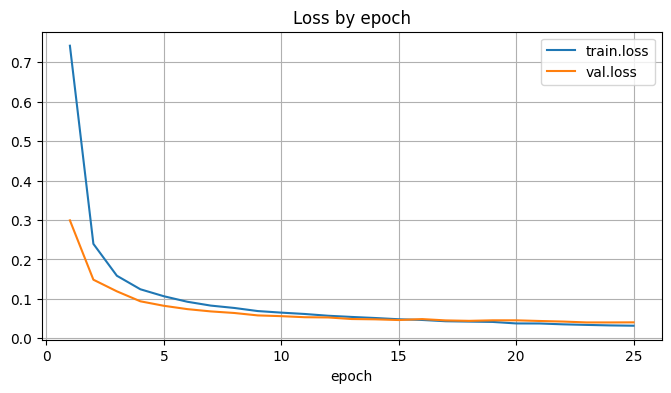

In [6]:
history_df.plot(x='epoch', y=['train.loss', 'val.loss'], figsize=(8, 4), grid=True, title='Loss by epoch')

<Axes: title={'center': 'Validation metrics by epoch'}, xlabel='epoch'>

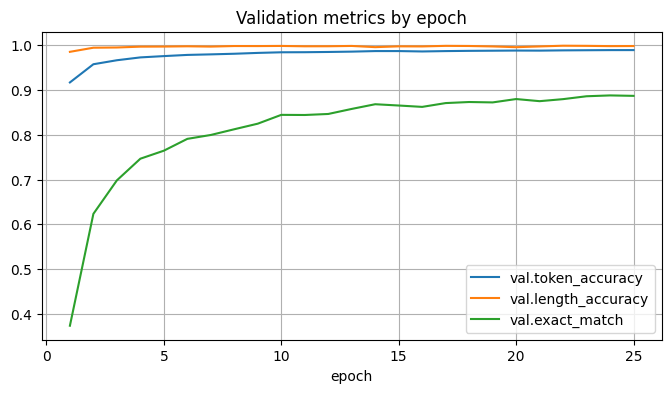

In [7]:
history_df.plot(
    x='epoch',
    y=['val.token_accuracy', 'val.length_accuracy', 'val.exact_match'],
    figsize=(8, 4),
    grid=True,
    title='Validation metrics by epoch',
)

## 5. Load a checkpoint

In [8]:
import torch
from irrm_codec.inverse_model import InverseModel

checkpoint = torch.load(output_dir / 'best.pt', map_location='cpu')
extra = checkpoint['extra']
model = InverseModel(
    embedding_dim=extra['embedding_dim'],
    max_len=extra.get('max_len', 40),
)
model.load_state_dict(checkpoint['model_state'])
model.eval()
checkpoint['metrics']

/scratch/ipykernel_1864484/2516080192.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(output_dir / 'best.pt', map_location='cpu')


{'loss': 0.040323072855797,
 'token_accuracy': 0.9890268611002572,
 'length_accuracy': 0.9979232594936709,
 'exact_match': 0.8878560126582279,
 'unk_fraction': 0.0}

## 6. Test the model on held-out examples

In [11]:
import numpy as np
from irrm_codec.dataio import load_airr_with_embeddings
from irrm_codec.tokenization import decode
from irrm_codec.utils import apply_standardizer, split_indices

df, emb, _merge_stats = load_airr_with_embeddings(
    airr_path=airr_path,
    embeddings_path=embeddings_path,
    locus='beta',
)

train_idx, val_idx, test_idx = split_indices(len(df), train_fraction=0.8, val_fraction=0.1, seed=42)
test_df = df.iloc[test_idx].reset_index(drop=True)
test_emb = apply_standardizer(
    emb[test_idx],
    np.load(output_dir / 'mean.npy'),
    np.load(output_dir / 'std.npy'),
)

sample_size = 1000
sample_emb = torch.tensor(test_emb[:sample_size], dtype=torch.float32)
pred_tokens, pred_lengths = model.generate(sample_emb, max_len=model.max_len)

results = pd.DataFrame({
    'target': test_df['junction_aa'].iloc[:sample_size].tolist(),
    'predicted': [decode(row.tolist()) for row in pred_tokens],
    'predicted_length': pred_lengths.tolist(),
})
results['target_length'] = results['target'].str.len()
results['exact_match'] = results['target'] == results['predicted']
results

,target,predicted,predicted_length,target_length,exact_match
0,CASSYRENYGYTF,CASSYRENYGYTF,13,13,True
1,CASSFGGTEAFF,CASSFGGTEAFF,12,12,True
2,CASSLAQNTEAFF,CASSLAQNTEAFF,13,13,True
3,CASSQVEGETQYF,CASSQVEGETQYF,13,13,True
4,CSVVGGGTDTQYF,CSVVGGGTDTQYF,13,13,True
...,...,...,...,...,...
995,CASRRQGYTDTQYF,CASRRQGYTDTQYF,14,14,True
996,CASSWGPTYEQYF,CASSWGPTYEQYF,13,13,True
997,CASSFSSGSGETQYF,CASSFSSGSGETQYF,15,15,True
998,CASSATSAGEQYF,CASSATSAGEQYF,13,13,True


In [16]:
results.exact_match.mean()

np.float64(0.878)

In [14]:
results[~results['exact_match']]

,target,predicted,predicted_length,target_length,exact_match
24,CASSHSGTSGQGAYNEQFF,CASSHSGTGQGAYNEQFF,19,19,False
27,CSAAVTGTGEQFF,CSVAVTGTGEQFF,13,13,False
29,CASSQDYLGAWGIQYF,CASSQDYLWGAAIQYF,16,16,False
46,CASSEGDTIFGKNIQYF,CASSEGDTFIGKNIQYF,17,17,False
64,CASSPGASGRFEQYF,CASSPGASGRYEQYF,15,15,False
...,...,...,...,...,...
943,CASTIGGDVDTQYF,CASTIGGDIDTQYF,14,14,False
952,CSGGGNEQFF,CSVGGNEQFF,10,10,False
956,CSADYGVDEQFF,CSVDYGVDEQFF,12,12,False
989,CASSGDSLSSGNTIYF,CASSDGSLSSGNTIYF,16,16,False
